In [28]:
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt

In [3]:
model = CmdStanModel(stan_file="bernoulli.stan")
data = {"N": 10, "y": [0, 1, 0, 0, 0, 0, 0, 0, 0, 1]}
fit = model.sample(data=data)

07:40:50 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:40:50 - cmdstanpy - INFO - CmdStan done processing.


In [10]:
fit.draws_pd("theta")

,theta
0,0.199182
1,0.179070
2,0.179469
3,0.253321
4,0.253607
...,...
3995,0.263676
3996,0.255779
3997,0.255779
3998,0.539113


<Axes: xlabel='$X$', ylabel='$Y$'>

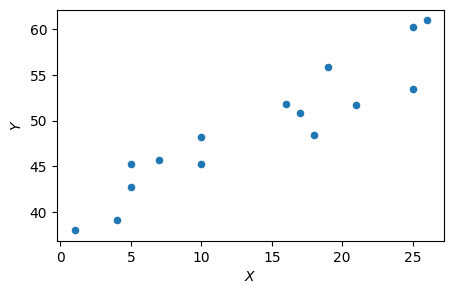

In [18]:
df = pd.read_csv("data-salary.csv")
df.plot.scatter("X", "Y", figsize=(5, 3), xlabel="$X$", ylabel="$Y$")

In [19]:
model = CmdStanModel(stan_file="model4-4.stan")

08:00:57 - cmdstanpy - INFO - compiling stan file /Users/mgreenbe/DATA335W2026/model4-4.stan to exe file /Users/mgreenbe/DATA335W2026/model4-4
08:01:02 - cmdstanpy - INFO - compiled model executable: /Users/mgreenbe/DATA335W2026/model4-4


In [25]:
data = {"N": len(df), "X": df["X"], "Y": df["Y"]}
fit = model.sample(data=data)

08:03:08 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:03:08 - cmdstanpy - INFO - CmdStan done processing.


In [27]:
theta = fit.draws_pd(["a", "b", "sigma"])

In [31]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-21.624200,0.042621,1.401780,1.096320,-24.599100,-21.237900,-20.131000,1250.94,1523.70,8687.05,1.00304
a,38.718600,0.041056,1.505770,1.427800,36.234700,38.695100,41.245100,1362.30,1511.02,9460.39,1.00331
b,0.751728,0.002451,0.093549,0.088097,0.602507,0.752332,0.907287,1483.15,1496.84,10299.70,1.00300
sigma,2.919770,0.018437,0.673233,0.592914,2.070930,2.805270,4.175370,1495.25,1927.28,10383.70,1.00076


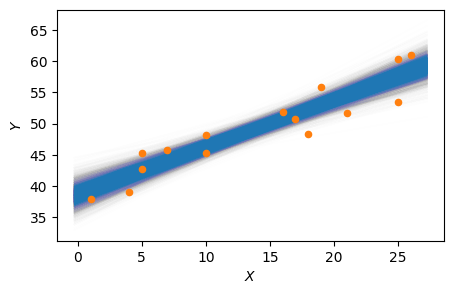

In [ ]:
a = theta["a"]
b = theta["b"]
x = df["X"]
df.plot.scatter("X", "Y", figsize=(5, 3), xlabel="$X$", ylabel="$Y$", color="C1")
x0, x1 = plt.xlim()
for a, b in zip(theta["a"], theta["b"]):
    plt.plot([x0, x1], [a + b * x0, a + b * x1], "C0", alpha=0.002, zorder=-1)

<Axes: xlabel='Income', ylabel='purchases per visit'>

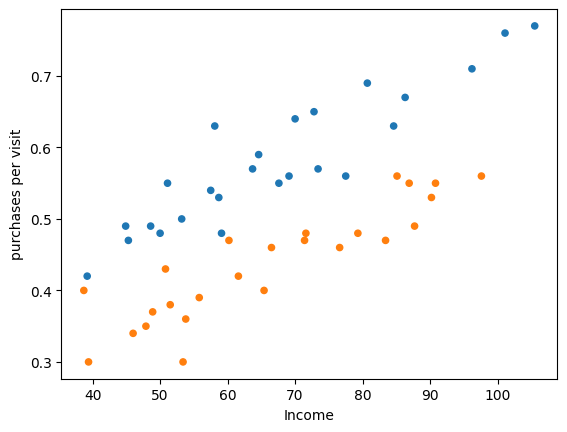

In [98]:
df = pd.read_csv("data-shopping-1.csv")
df.plot.scatter(
    "Income", "Y", c=np.where(df["Sex"], "C0", "C1"), ylabel="purchases per visit"  # type: ignore
)

In [101]:
model = CmdStanModel(stan_file="model5-3.stan")

17:46:16 - cmdstanpy - INFO - compiling stan file /Users/mgreenbe/DATA335W2026/model5-3.stan to exe file /Users/mgreenbe/DATA335W2026/model5-3
17:46:21 - cmdstanpy - INFO - compiled model executable: /Users/mgreenbe/DATA335W2026/model5-3


In [102]:
data = {"N": len(df), "Sex": df["Sex"], "Income": df["Income"], "Y": df["Y"]}
fit = model.sample(data=data)

17:46:24 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:46:26 - cmdstanpy - INFO - CmdStan done processing.


In [103]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,135.966000,0.045890,1.521370,1.255780,132.954000,136.318000,137.685000,1233.96,1337.58,527.558,1.00098
b[1],0.148398,0.000522,0.022164,0.020648,0.113217,0.148177,0.186314,1847.22,1640.48,789.748,1.00065
b[2],0.137668,0.000253,0.010881,0.011072,0.120191,0.137424,0.155744,1868.68,1767.89,798.924,1.00228
b[3],0.004375,0.000007,0.000309,0.000298,0.003856,0.004375,0.004868,2019.38,1819.61,863.350,1.00021
sigma,0.038088,0.000094,0.004090,0.003942,0.032166,0.037620,0.045423,1884.04,1451.24,805.491,1.00289


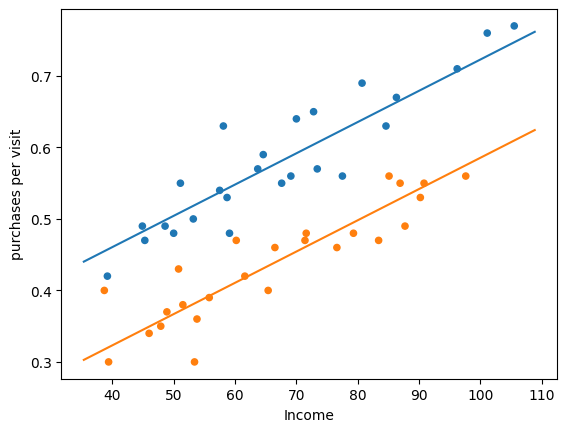

In [119]:
df.plot.scatter(
    "Income", "Y", c=np.where(df["Sex"], "C0", "C1"), ylabel="purchases per visit"  # type: ignore
)
_, a, b, c, __ = fit.summary()["50%"]
t = np.array(plt.xlim())
plt.plot(t, a + b + c*t)
plt.plot(t, a + c*t)

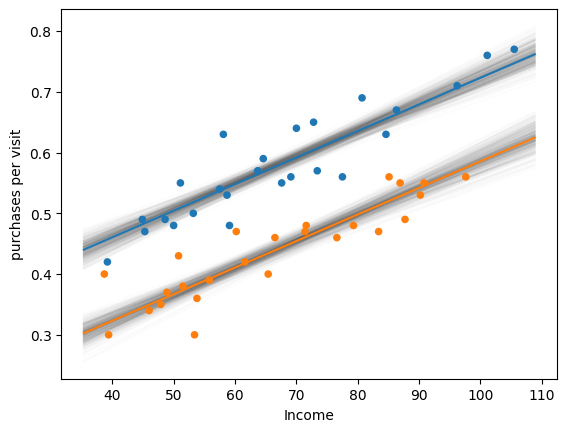

In [142]:
df.plot.scatter(
    "Income", "Y", c=np.where(df["Sex"], "C0", "C1"), ylabel="purchases per visit"  # type: ignore
)

_, a, b, c, __ = fit.summary()["50%"]
t = np.array(plt.xlim())
plt.plot(t, a + b + c*t)
plt.plot(t, a + c*t)

for i, (a, b, c) in fit.draws_pd()[["b[1]", "b[2]", "b[3]"]].iterrows():
    plt.plot(t, a + b + c*t, "k", alpha=0.01, zorder=-1)
    plt.plot(t, a + c*t, "k", alpha=0.01, zorder=-1)
    if i > 300:
        break

In [113]:
a, b, c

(0.148177, 0.137424, 0.0043747)

In [112]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,135.966000,0.045890,1.521370,1.255780,132.954000,136.318000,137.685000,1233.96,1337.58,527.558,1.00098
b[1],0.148398,0.000522,0.022164,0.020648,0.113217,0.148177,0.186314,1847.22,1640.48,789.748,1.00065
b[2],0.137668,0.000253,0.010881,0.011072,0.120191,0.137424,0.155744,1868.68,1767.89,798.924,1.00228
b[3],0.004375,0.000007,0.000309,0.000298,0.003856,0.004375,0.004868,2019.38,1819.61,863.350,1.00021
sigma,0.038088,0.000094,0.004090,0.003942,0.032166,0.037620,0.045423,1884.04,1451.24,805.491,1.00289
